In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

print(df.shape)
print(df.info())

df.describe()
df.describe(include='object')

(374, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
None


,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


In [6]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [8]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

In [10]:
df.duplicated().sum()

0

In [12]:
print(df.nunique())

Person ID                  374
Gender                       2
Age                         31
Occupation                  11
Sleep Duration              27
Quality of Sleep             6
Physical Activity Level     16
Stress Level                 6
BMI Category                 4
Blood Pressure              25
Heart Rate                  19
Daily Steps                 20
Sleep Disorder               3
dtype: int64


In [20]:
df['BMI Category'] = df['BMI Category'].replace({
    'Normal Weight':'Normal'
})

In [22]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
None


In [24]:
print(df.memory_usage(deep=True))

Index                        132
Person ID                   2992
Gender                     20192
Age                         2992
Occupation                 21056
Sleep Duration              2992
Quality of Sleep            2992
Physical Activity Level     2992
Stress Level                2992
BMI Category               21152
Blood Pressure             20570
Heart Rate                  2992
Daily Steps                 2992
Sleep Disorder             16077
dtype: int64


In [26]:
print(df['Gender'].unique())
print(df['Gender'].value_counts())

['Male' 'Female']
Gender
Male      189
Female    185
Name: count, dtype: int64


In [28]:
print(df['Occupation'].unique())

['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']


In [30]:
print(df['BMI Category'].unique())
print(df['BMI Category'].value_counts())

['Overweight' 'Normal' 'Obese']
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


In [32]:
print(df['Sleep Disorder'].unique())
print(df['Sleep Disorder'].value_counts())

[nan 'Sleep Apnea' 'Insomnia']
Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64


In [34]:
print("\nChecking for leading/trailing spaces...")
has_spaces = False
for col in df.select_dtypes(include='object').columns:
    for val in df[col].unique():
        if str(val).strip() != str(val):
            print(f"Found space in {col}: '{val}'")
            has_spaces = True
if not has_spaces:
    print("✓ No leading/trailing spaces found")


Checking for leading/trailing spaces...
✓ No leading/trailing spaces found


In [40]:
print("\nSleep Duration Statistics:")
print(f"Min: {df['Sleep Duration'].min()}, Max: {df['Sleep Duration'].max()}")
print(f"Values < 0: {(df['Sleep Duration'] < 0).sum()}")
print(f"Values > 12: {(df['Sleep Duration'] > 12).sum()}")
print("✓ All sleep durations valid")
 
print("\nQuality of Sleep Statistics:")
print(f"Min: {df['Quality of Sleep'].min()}, Max: {df['Quality of Sleep'].max()}")
print(f"Expected range: 1-10")
 
print("\nPhysical Activity Level Statistics:")
print(f"Min: {df['Physical Activity Level'].min()}, Max: {df['Physical Activity Level'].max()}")
 
print("\nStress Level Statistics:")
print(f"Min: {df['Stress Level'].min()}, Max: {df['Stress Level'].max()}")
 
print("\nHeart Rate Statistics:")
print(f"Min: {df['Heart Rate'].min()}, Max: {df['Heart Rate'].max()}")
print(f"Values < 40: {(df['Heart Rate'] < 40).sum()}")
print(f"Values > 120: {(df['Heart Rate'] > 120).sum()}")
 
print("\nDaily Steps Statistics:")
print(f"Min: {df['Daily Steps'].min()}, Max: {df['Daily Steps'].max()}")
 
print("\n--- DATA TYPE ISSUES ---")
print("\nChecking data types:")
print(df.dtypes)
 
print("\nBlood Pressure Check:")
print(f"Data Type: {df['Blood Pressure'].dtype}")
print(f"Sample values: {df['Blood Pressure'].head()}")
print("Note: Blood Pressure stored as object (string) - needs conversion")
 
print("\n### FINDINGS:")
print(f"✓ No missing values detected")
print(f"✗ Found {df.duplicated().sum()} duplicate records ({(df.duplicated().sum()/len(df))*100:.2f}%)")
print(f"✓ No major text inconsistencies")
print(f"✓ No invalid numeric values")
print(f"• Blood Pressure stored as string - needs conversion to numeric")
print(f"• All other data types appropriate")


Sleep Duration Statistics:
Min: 5.8, Max: 8.5
Values < 0: 0
Values > 12: 0
✓ All sleep durations valid

Quality of Sleep Statistics:
Min: 4, Max: 9
Expected range: 1-10

Physical Activity Level Statistics:
Min: 30, Max: 90

Stress Level Statistics:
Min: 3, Max: 8

Heart Rate Statistics:
Min: 65, Max: 86
Values < 40: 0
Values > 120: 0

Daily Steps Statistics:
Min: 3000, Max: 10000

--- DATA TYPE ISSUES ---

Checking data types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Blood Pressure Check:
Data Type: object
Sample values: 0    126/83
1    125/80
2    125/80
3    14

In [42]:
df_clean = df.copy()

In [44]:
print(f"Original rows: {len(df_clean)}")
df_clean = df_clean.drop_duplicates()
print(f"After removing duplicates: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Original rows: 374
After removing duplicates: 374
Rows removed: 0


In [46]:
df_clean['Gender'] = df_clean['Gender'].str.strip().str.capitalize()
print(f"Gender values: {df_clean['Gender'].unique()}")

Gender values: ['Male' 'Female']


In [48]:
df_clean['Occupation'] = df_clean['Occupation'].str.strip().str.title()
print(f"Unique Occupations: {df_clean['Occupation'].nunique()}")

Unique Occupations: 11


In [50]:
df_clean['BMI Category'] = df_clean['BMI Category'].str.strip().str.title()
print(f"BMI Category values: {df_clean['BMI Category'].unique()}")

BMI Category values: ['Overweight' 'Normal' 'Obese']


In [52]:
df_clean['Sleep Disorder'] = df_clean['Sleep Disorder'].str.strip().str.title()
print(f"Sleep Disorder values: {df_clean['Sleep Disorder'].unique()}")

Sleep Disorder values: [nan 'Sleep Apnea' 'Insomnia']


In [54]:
print(df_clean['Blood Pressure'].head(10))


0    126/83
1    125/80
2    125/80
3    140/90
4    140/90
5    140/90
6    140/90
7    120/80
8    120/80
9    120/80
Name: Blood Pressure, dtype: object


In [58]:
df_clean[['Systolic_BP', 'Diastolic_BP']] = df_clean['Blood Pressure'].str.split('/', expand=True)
df_clean['Systolic_BP'] = pd.to_numeric(df_clean['Systolic_BP'])
df_clean['Diastolic_BP'] = pd.to_numeric(df_clean['Diastolic_BP'])

In [60]:
print(df_clean[['Blood Pressure', 'Systolic_BP', 'Diastolic_BP']].head())
print(f"\nSystolic BP - Min: {df_clean['Systolic_BP'].min()}, Max: {df_clean['Systolic_BP'].max()}")
print(f"Diastolic BP - Min: {df_clean['Diastolic_BP'].min()}, Max: {df_clean['Diastolic_BP'].max()}")

  Blood Pressure  Systolic_BP  Diastolic_BP
0         126/83          126            83
1         125/80          125            80
2         125/80          125            80
3         140/90          140            90
4         140/90          140            90

Systolic BP - Min: 115, Max: 142
Diastolic BP - Min: 75, Max: 95


In [62]:
print(df_clean.dtypes)


Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
Systolic_BP                  int64
Diastolic_BP                 int64
dtype: object


In [64]:
print(df_clean.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
Systolic_BP                  0
Diastolic_BP                 0
dtype: int64


In [66]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
 13  Systolic_BP              374 non-null    int64  
 14  Diastolic_BP             3

In [68]:
print(f"✓ Removed {len(df) - len(df_clean)} duplicate records")
print(f"✓ Standardized all text fields")
print(f"✓ Created Systolic_BP and Diastolic_BP columns")
print(f"✓ Final dataset shape: {df_clean.shape}")
print(f"✓ No missing values in cleaned dataset")

✓ Removed 0 duplicate records
✓ Standardized all text fields
✓ Created Systolic_BP and Diastolic_BP columns
✓ Final dataset shape: (374, 15)
✓ No missing values in cleaned dataset


In [70]:
df_clean['Age_Group'] = pd.cut(df_clean['Age'], 
                                bins=[0, 20, 30, 40, 50, 60, 100],
                                labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+'])
print("Age Groups created:")
print(df_clean['Age_Group'].value_counts().sort_index())
print("Business Value: Analyze sleep patterns across age demographics")

Age Groups created:
Age_Group
<20        0
20-30     32
30-40    133
40-50    133
50-60     76
60+        0
Name: count, dtype: int64
Business Value: Analyze sleep patterns across age demographics


In [72]:
df_clean['Sleep_Quality_Category'] = pd.cut(df_clean['Quality of Sleep'], 
                                             bins=[0, 4, 7, 10],
                                             labels=['Poor', 'Average', 'Good'])
print("Sleep Quality Categories:")
print(df_clean['Sleep_Quality_Category'].value_counts())
print("Business Value: Identify individuals with poor/average/good sleep")

Sleep Quality Categories:
Sleep_Quality_Category
Average    189
Good       180
Poor         5
Name: count, dtype: int64
Business Value: Identify individuals with poor/average/good sleep


In [74]:
df_clean['Stress_Category'] = pd.cut(df_clean['Stress Level'],
                                      bins=[0, 4, 7, 10],
                                      labels=['Low', 'Medium', 'High'])
print("Stress Categories:")
print(df_clean['Stress_Category'].value_counts())
print("Business Value: Understand stress distribution and impact on sleep")

Stress Categories:
Stress_Category
Medium    163
Low       141
High       70
Name: count, dtype: int64
Business Value: Understand stress distribution and impact on sleep


In [76]:
df_clean['Activity_Level'] = pd.cut(df_clean['Physical Activity Level'],
                                     bins=[-1, 30, 60, 100],
                                     labels=['Low', 'Medium', 'High'])
print("Activity Levels:")
print(df_clean['Activity_Level'].value_counts())
print("Business Value: Correlate physical activity with sleep quality")

Activity Levels:
Activity_Level
Medium    163
High      143
Low        68
Name: count, dtype: int64
Business Value: Correlate physical activity with sleep quality


In [78]:
def categorize_bp(systolic, diastolic):
    if systolic < 120 and diastolic < 80:
        return 'Normal'
    elif systolic < 130 and diastolic < 80:
        return 'Elevated'
    elif systolic < 140 or diastolic < 90:
        return 'Stage 1 Hypertension'
    else:
        return 'Stage 2 Hypertension'
 
df_clean['BP_Category'] = df_clean.apply(lambda row: categorize_bp(row['Systolic_BP'], row['Diastolic_BP']), axis=1)
print("Blood Pressure Categories:")
print(df_clean['BP_Category'].value_counts())
print("Business Value: Monitor cardiovascular health risk")

Blood Pressure Categories:
BP_Category
Stage 1 Hypertension    261
Stage 2 Hypertension     71
Normal                   41
Elevated                  1
Name: count, dtype: int64
Business Value: Monitor cardiovascular health risk


In [80]:
df_clean['Heart_Rate_Status'] = pd.cut(df_clean['Heart Rate'],
                                        bins=[0, 60, 100, 200],
                                        labels=['Normal', 'Elevated', 'High'])
print("Heart Rate Status:")
print(df_clean['Heart_Rate_Status'].value_counts())
print("Business Value: Assess cardiovascular health indicators")

Heart Rate Status:
Heart_Rate_Status
Elevated    374
Normal        0
High          0
Name: count, dtype: int64
Business Value: Assess cardiovascular health indicators


In [82]:
print(f"Final dataset shape: {df_clean.shape}")

Final dataset shape: (374, 21)


In [84]:
for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Mean: {df_clean[col].mean():.2f}")
    print(f"  Median: {df_clean[col].median():.2f}")
    print(f"  Mode: {df_clean[col].mode().values[0]:.2f}")
    print(f"  Min: {df_clean[col].min():.2f}")
    print(f"  Max: {df_clean[col].max():.2f}")
    print(f"  Range: {df_clean[col].max() - df_clean[col].min():.2f}")
    print(f"  Std Dev: {df_clean[col].std():.2f}")
    print(f"  Variance: {df_clean[col].var():.2f}")
    print(f"  Skewness: {df_clean[col].skew():.2f}")
    print(f"  Kurtosis: {df_clean[col].kurtosis():.2f}")


Age:
  Mean: 42.18
  Median: 43.00
  Mode: 43.00
  Min: 27.00
  Max: 59.00
  Range: 32.00
  Std Dev: 8.67
  Variance: 75.22
  Skewness: 0.26
  Kurtosis: -0.91

Sleep Duration:
  Mean: 7.13
  Median: 7.20
  Mode: 7.20
  Min: 5.80
  Max: 8.50
  Range: 2.70
  Std Dev: 0.80
  Variance: 0.63
  Skewness: 0.04
  Kurtosis: -1.29

Quality of Sleep:
  Mean: 7.31
  Median: 7.00
  Mode: 8.00
  Min: 4.00
  Max: 9.00
  Range: 5.00
  Std Dev: 1.20
  Variance: 1.43
  Skewness: -0.21
  Kurtosis: -0.75

Physical Activity Level:
  Mean: 59.17
  Median: 60.00
  Mode: 60.00
  Min: 30.00
  Max: 90.00
  Range: 60.00
  Std Dev: 20.83
  Variance: 433.92
  Skewness: 0.07
  Kurtosis: -1.27

Stress Level:
  Mean: 5.39
  Median: 5.00
  Mode: 3.00
  Min: 3.00
  Max: 8.00
  Range: 5.00
  Std Dev: 1.77
  Variance: 3.15
  Skewness: 0.15
  Kurtosis: -1.33

Heart Rate:
  Mean: 70.17
  Median: 70.00
  Mode: 68.00
  Min: 65.00
  Max: 86.00
  Range: 21.00
  Std Dev: 4.14
  Variance: 17.10
  Skewness: 1.22
  Kurtosis: 2.29

In [86]:
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder', 
                    'Age_Group', 'Sleep_Quality_Category', 'Stress_Category', 
                    'Activity_Level', 'BP_Category']
 
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())
    print(f"Percentages:")
    print((df_clean[col].value_counts() / len(df_clean) * 100).round(2))


Gender:
Gender
Male      189
Female    185
Name: count, dtype: int64
Percentages:
Gender
Male      50.53
Female    49.47
Name: count, dtype: float64

Occupation:
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64
Percentages:
Occupation
Nurse                   19.52
Doctor                  18.98
Engineer                16.84
Lawyer                  12.57
Teacher                 10.70
Accountant               9.89
Salesperson              8.56
Software Engineer        1.07
Scientist                1.07
Sales Representative     0.53
Manager                  0.27
Name: count, dtype: float64

BMI Category:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64
Percentages:


In [105]:
print("\n--- IQR METHOD ---")
outlier_summary = []
 
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df_clean)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': outlier_pct
    })
    
    if outlier_count > 0:
        print(f"\n{col}:")
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Outliers: {outlier_count} ({outlier_pct:.2f}%)")
        print(f"  Outlier values: {outliers[col].values[:5]}")
 
outlier_df = pd.DataFrame(outlier_summary)
print("\n--- Outlier Summary Table ---")
print(outlier_df[outlier_df['Outlier_Count'] > 0])


--- IQR METHOD ---

Heart Rate:
  Q1: 68.00, Q3: 72.00, IQR: 4.00
  Bounds: [62.00, 78.00]
  Outliers: 15 (4.01%)
  Outlier values: [85 85 85 82 80]

--- Outlier Summary Table ---
       Column    Q1    Q3  IQR  Lower_Bound  Upper_Bound  Outlier_Count  \
5  Heart Rate  68.0  72.0  4.0         62.0         78.0             15   

   Outlier_Percentage  
5            4.010695  


In [101]:
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_val:.3f}")
 
print("\nModerate Correlations (0.3 < |r| < 0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if 0.3 < abs(corr_val) <= 0.5:
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_val:.3f}")

Age vs Systolic_BP: 0.606
Age vs Diastolic_BP: 0.594
Sleep Duration vs Quality of Sleep: 0.883
Sleep Duration vs Stress Level: -0.811
Sleep Duration vs Heart Rate: -0.516
Quality of Sleep vs Stress Level: -0.899
Quality of Sleep vs Heart Rate: -0.660
Physical Activity Level vs Daily Steps: 0.773
Stress Level vs Heart Rate: 0.670
Systolic_BP vs Diastolic_BP: 0.973

Moderate Correlations (0.3 < |r| < 0.5):
Age vs Sleep Duration: 0.345
Age vs Quality of Sleep: 0.474
Age vs Stress Level: -0.422
Physical Activity Level vs Diastolic_BP: 0.383


In [109]:
print(df_clean.groupby('Gender')['Sleep Duration'].agg(['mean', 'median', 'std', 'count']))
print(df_clean.groupby('Gender')['Quality of Sleep'].agg(['mean', 'median', 'std']))
print(df_clean.groupby('Sleep Disorder')['Quality of Sleep'].agg(['mean', 'median', 'std', 'count']))
print(df_clean.groupby('BMI Category')['Sleep Duration'].agg(['mean', 'median', 'std', 'count']))
print(df_clean.groupby('Sleep Disorder')['Stress Level'].agg(['mean', 'median', 'std']))
print(df_clean.groupby('Sleep Disorder')['Physical Activity Level'].agg(['mean', 'median', 'std']))
ct1 = pd.crosstab(df_clean['Gender'], df_clean['Sleep Disorder'], margins=True)
print(ct1)
ct2 = pd.crosstab(df_clean['BMI Category'], df_clean['Sleep Disorder'])
print(ct2)
top_occupations = df_clean['Occupation'].value_counts().head(5).index
ct3 = pd.crosstab(df_clean[df_clean['Occupation'].isin(top_occupations)]['Occupation'], 
                   df_clean[df_clean['Occupation'].isin(top_occupations)]['Sleep Disorder'])
print(ct3)

            mean  median       std  count
Gender                                   
Female  7.229730     7.2  0.879434    185
Male    7.036508     7.2  0.693197    189
            mean  median       std
Gender                            
Female  7.664865     8.0  1.279482
Male    6.968254     7.0  0.999493
                    mean  median       std  count
Sleep Disorder                                   
Insomnia        6.532468     7.0  0.804337     77
Sleep Apnea     7.205128     6.0  1.646397     78
                  mean  median       std  count
BMI Category                                   
Normal        7.387963     7.5  0.718165    216
Obese         6.960000     7.3  0.883428     10
Overweight    6.770270     6.5  0.757768    148
                    mean  median       std
Sleep Disorder                            
Insomnia        5.870130     7.0  1.463150
Sleep Apnea     5.666667     7.0  2.333643
                     mean  median        std
Sleep Disorder                     

<Axes: xlabel='Sleep Duration', ylabel='Quality of Sleep'>

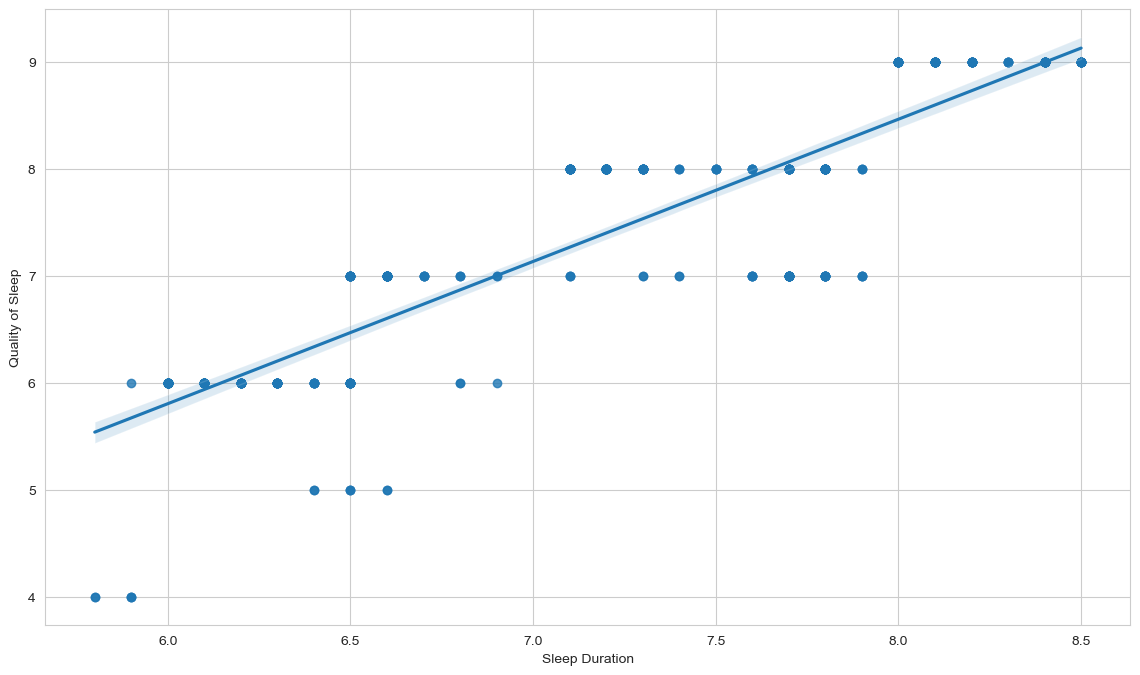

In [111]:
#Quality of Sleep vs Sleep Duration
sns.regplot(
    x='Sleep Duration',
    y='Quality of Sleep',
    data=df
)

<Axes: xlabel='Stress Level', ylabel='Quality of Sleep'>

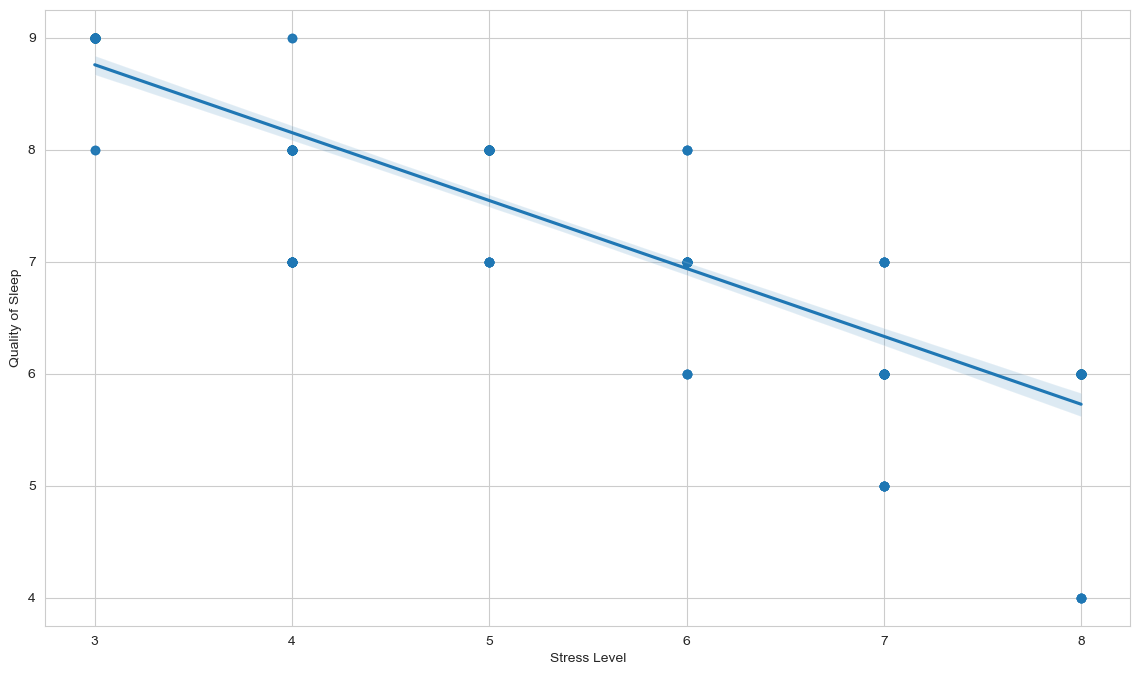

In [113]:
#Quality of Sleep vs Stress Level
sns.regplot(
    x='Stress Level',
    y='Quality of Sleep',
    data=df
)

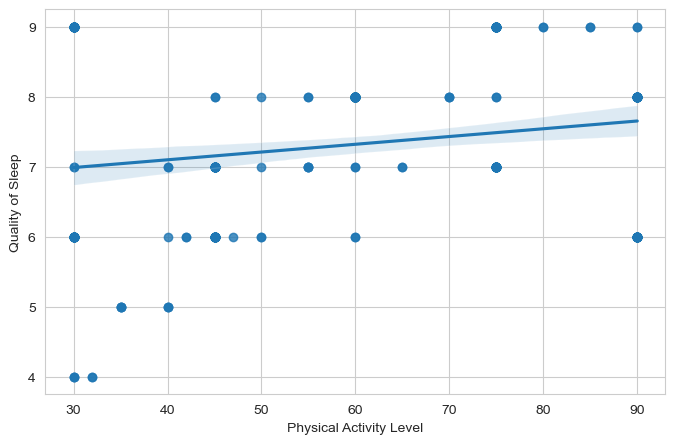

In [137]:
#Physical Activity vs Sleep Quality
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Physical Activity Level',
    y='Quality of Sleep'
)

plt.show()

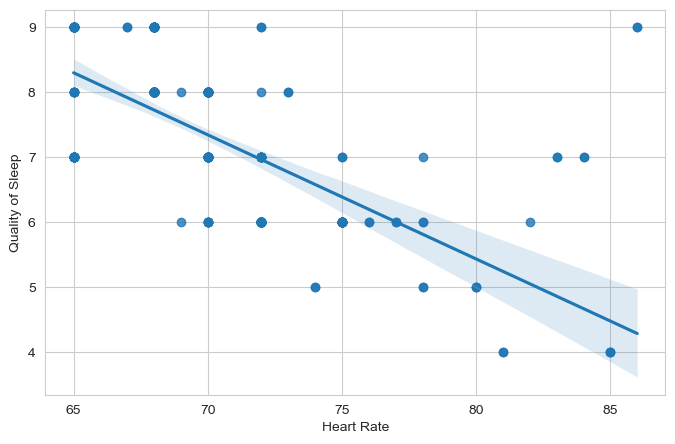

In [141]:
#Heart Rate vs Sleep Quality
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Heart Rate',
    y='Quality of Sleep'
)

plt.show()

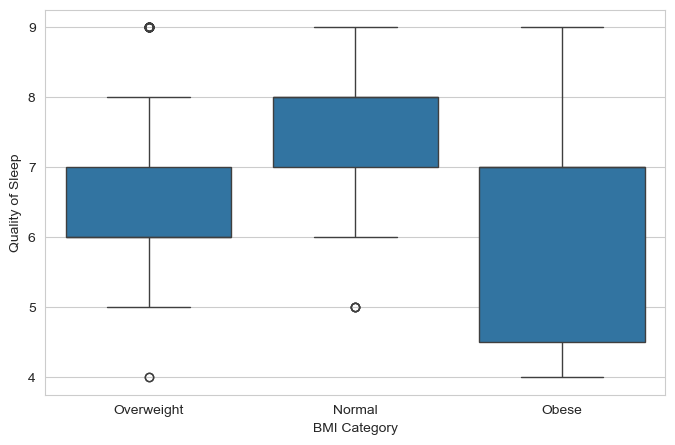

In [143]:
#BMI vs Sleep Quality
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='BMI Category',
    y='Quality of Sleep'
)

plt.show()

In [115]:
#Sleep Disorder vs Gender
pd.crosstab(
    df['Gender'],
    df['Sleep Disorder']
)

Sleep Disorder,Insomnia,Sleep Apnea
Gender,,
Female,36,67
Male,41,11


<Axes: xlabel='Occupation', ylabel='Quality of Sleep'>

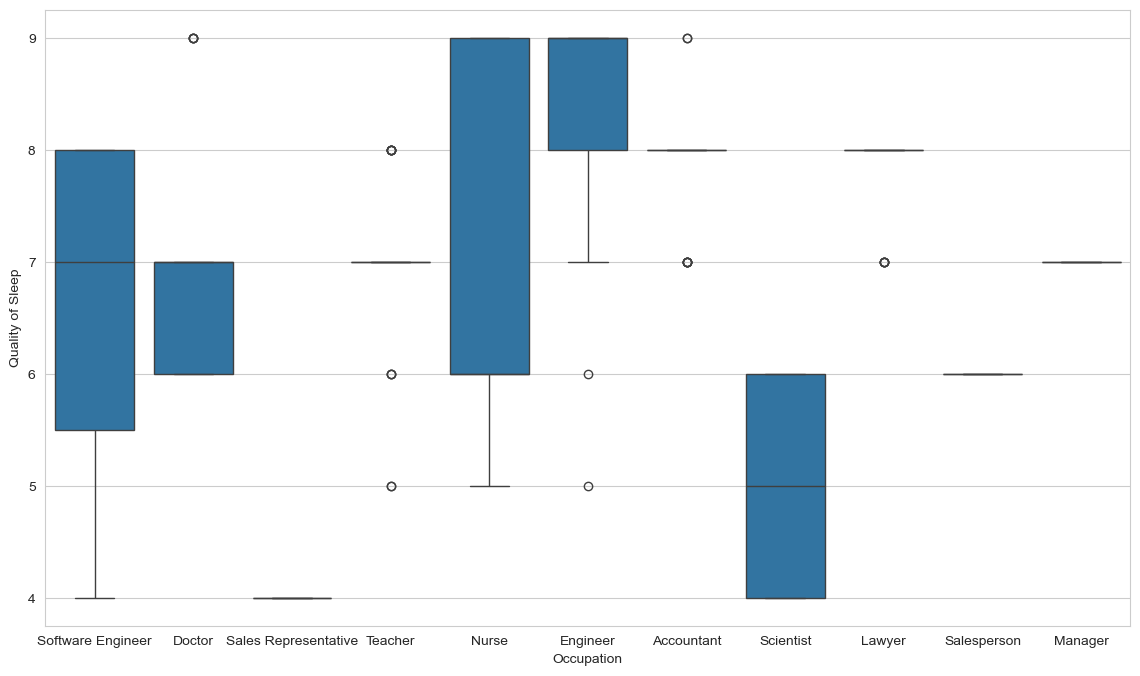

In [133]:
#Sleep Quality by Occupation
sns.boxplot(
    x='Occupation',
    y='Quality of Sleep',
    data=df
)

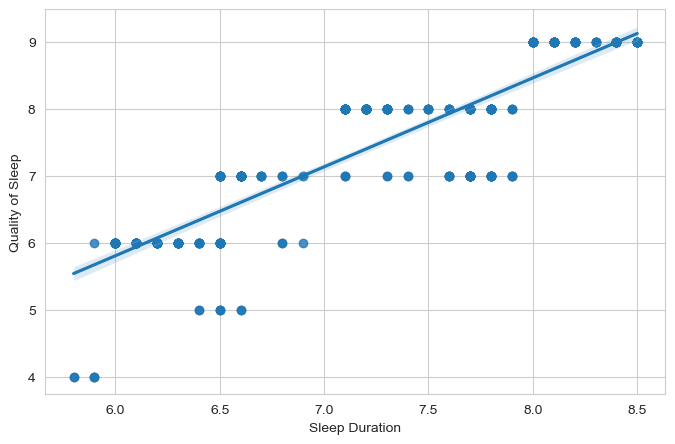

<Axes: >

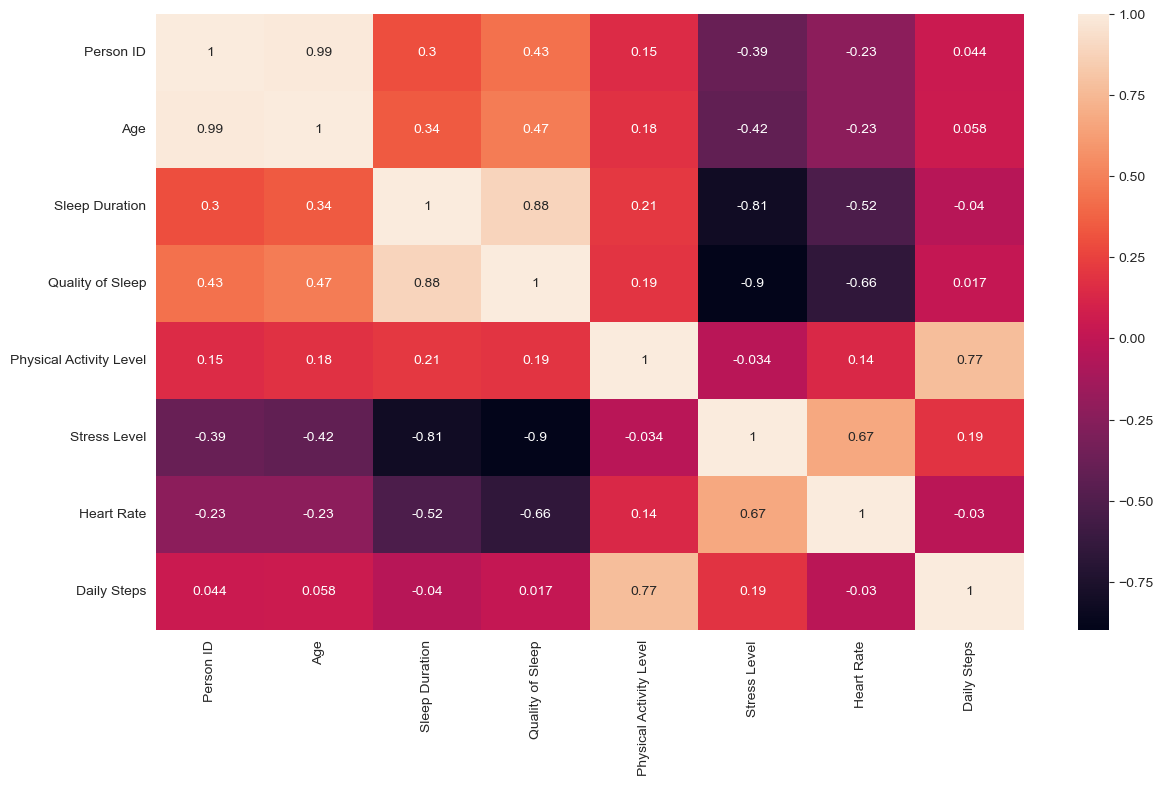

In [119]:
#Correlation heatmap
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

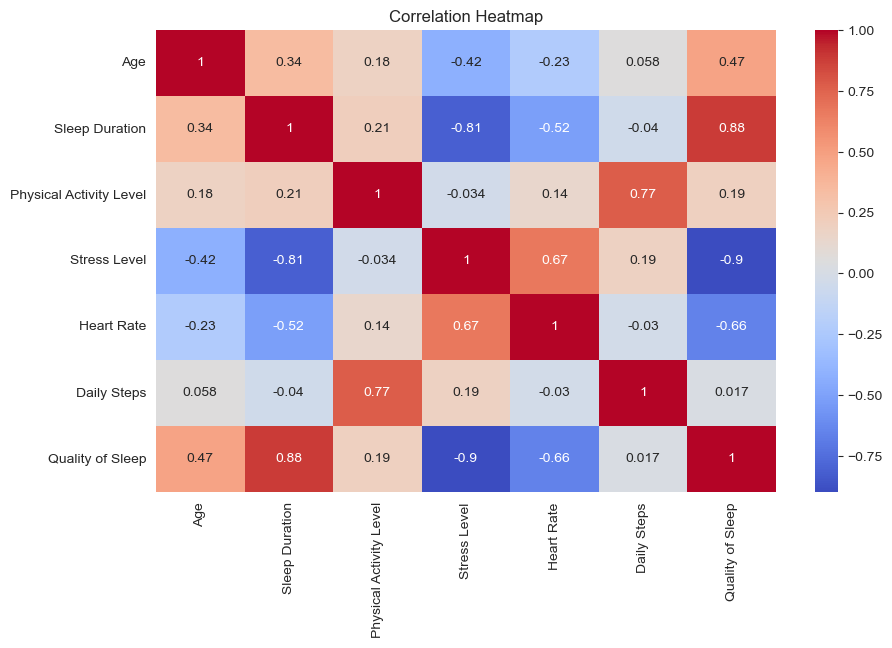

In [131]:
corr_cols = [
    'Age',
    'Sleep Duration',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Quality of Sleep'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()